<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1I8kDikouqpH4hf7JBiSYAeNT2IO52T-T" width=600 height=480/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Generative adversarial networks</b></h3>



В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации

In [1]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set(style='darkgrid', font_scale=1.2)

## Часть 1. Подготовка данных (0.5 балла)

В качестве обучающей выборки возьмем часть датасета [Flickr Faces](https://github.com/NVlabs/ffhq-dataset), который содержит изображения лиц людей в высоком разрешении (1024х1024). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно [здесь](https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory) и  [здесь](https://drive.google.com/file/d/1inyvLrN5wKBGCxQ4znMKBc64uL4uP_2x/view?usp=drive_link)

Давайте загрузим наши изображения. Напишите функцию, которая строит DataLoader для изображений, при этом меняя их размер до нужного значения (размер 1024 слишком большой, поэтому мы рекомендуем взять размер 128 либо немного больше)

In [4]:
DATA_PATH = 'C:\\prj\\DLS\\data\\faces_dataset_small'
# DATA_PATH_128 = 'C:\\prj\\DLS\\data\\faces_128'
DATA_PATH_128 = '/content/faces_128/faces_128'

### Преобразование набора данных

In [ ]:
import os
from PIL import Image


os.makedirs(DATA_PATH_128, exist_ok=True)

for filename in os.listdir(DATA_PATH):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
        try:
            img_path = os.path.join(DATA_PATH, filename)
            img = Image.open(img_path)

            img_resized = img.resize((128, 128), Image.LANCZOS)

            output_path = os.path.join(DATA_PATH_128, filename)
            img_resized.save(output_path)

            print(f"Processed: {filename}")
        except Exception as e:
            print(f"Error processing {filename}: {str(e)}")

print("All images have been resized")

> Часть работ проводил на локальном компьютере, поэтому преобразование очень помогло. Архив размещен на https://disk.yandex.ru/d/DDKHrbQJNe-yJA (100М)

### Распаковка на colab

In [3]:
!unzip /content/sample_data/faces_128.zip -d faces_128

Archive:  /content/sample_data/faces_128.zip
   creating: faces_128/faces_128/
  inflating: faces_128/faces_128/00055.png  
  inflating: faces_128/faces_128/00237.png  
  inflating: faces_128/faces_128/00240.png  
  inflating: faces_128/faces_128/00241.png  
  inflating: faces_128/faces_128/00242.png  
  inflating: faces_128/faces_128/00243.png  
  inflating: faces_128/faces_128/00244.png  
  inflating: faces_128/faces_128/00245.png  
  inflating: faces_128/faces_128/00246.png  
  inflating: faces_128/faces_128/00247.png  
  inflating: faces_128/faces_128/00248.png  
  inflating: faces_128/faces_128/00249.png  
  inflating: faces_128/faces_128/00253.png  
  inflating: faces_128/faces_128/00255.png  
  inflating: faces_128/faces_128/00257.png  
  inflating: faces_128/faces_128/00258.png  
  inflating: faces_128/faces_128/00259.png  
  inflating: faces_128/faces_128/00260.png  
  inflating: faces_128/faces_128/00261.png  
  inflating: faces_128/faces_128/00262.png  
  inflating: faces_12

### Создание Dataloader

In [ ]:
import os
from torch.utils.data import Dataset
from PIL import Image

class FlatImageFolder(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir)
                           if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)

        # Возвращаем image и пустой label (0)
        return image

def get_dataloader(batch_size):
    """
    Builds dataloader for training data.
    :param batch_size: batch_size of the dataloader
    :returns: DataLoader object
    """
    transform = tt.Compose([
        # tt.Resize((128, 128)),  # Явно указываем размер
        tt.ToTensor(),
    ])

    # Используем наш FlatImageFolder вместо ImageFolder
    dataset = FlatImageFolder(root_dir=DATA_PATH_128, transform=transform)

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        # num_workers=2
    )

    return dataloader

In [5]:

def show_images(dataloader, num_images=5):
    images = next(iter(dataloader))  # Игнорируем labels

    fig, axes = plt.subplots(1, num_images, figsize=(15, 3))
    for i in range(num_images):
        img = images[i].numpy().transpose((1, 2, 0))
        # Для изображений с нормализацией может потребоваться обратная нормализация
        img = np.clip(img, 0, 1)  # Обеспечиваем корректный диапазон значений
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.show()

### Проверка работы Dataloader

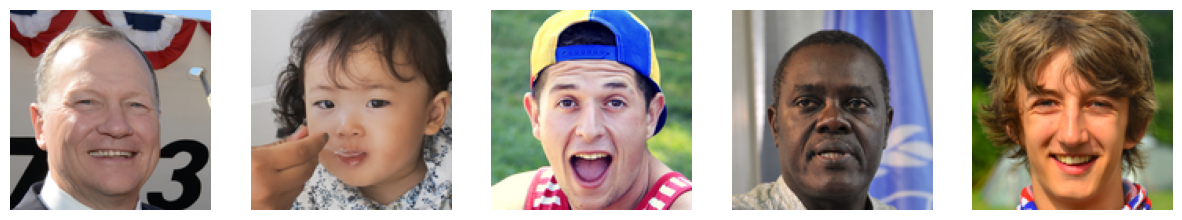

In [6]:
batch_size = 32
dataloader = get_dataloader(batch_size)
show_images(dataloader, 5)

## Часть 2. Построение и обучение модели (2 балла)

Сконструируйте генератор и дискриминатор. Помните, что:
* дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера 1)

* генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`

In [8]:
import torch
import torch.nn as nn

# Размеры
image_size = 128
latent_size = 100
n_channels = 3  # RGB
nf = 64  # Число фильтров в первом слое

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.main = nn.Sequential(
            # Вход: latent_size x 1 x 1
            nn.ConvTranspose2d(latent_size, nf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(nf * 16),
            nn.ReLU(True),
            # 4x4

            nn.ConvTranspose2d(nf * 16, nf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(nf * 8),
            nn.ReLU(True),
            # 8x8

            nn.ConvTranspose2d(nf * 8, nf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(nf * 4),
            nn.ReLU(True),
            # 16x16

            nn.ConvTranspose2d(nf * 4, nf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(nf * 2),
            nn.ReLU(True),
            # 32x32

            nn.ConvTranspose2d(nf * 2, nf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(nf),
            nn.ReLU(True),
            # 64x64

            nn.ConvTranspose2d(nf, n_channels, 4, 2, 1, bias=False),
            nn.Tanh()
            # 128x128
        )

    def forward(self, input):
        return self.main(input)

In [9]:

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.main = nn.Sequential(
            # Вход: 3 x 128 x 128
            nn.Conv2d(n_channels, nf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 64x64

            nn.Conv2d(nf, nf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(nf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # 32x32

            nn.Conv2d(nf * 2, nf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(nf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # 16x16

            nn.Conv2d(nf * 4, nf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(nf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # 8x8

            nn.Conv2d(nf * 8, nf * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(nf * 16),
            nn.LeakyReLU(0.2, inplace=True),
            # 4x4

            nn.Conv2d(nf * 16, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

# Инициализация моделей
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Проверка архитектуры

In [10]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Инициализируем веса
generator.apply(weights_init)
discriminator.apply(weights_init)

print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): BatchN

Перейдем теперь к обучению нашего GANа. Алгоритм обучения следующий:
1. Учим дискриминатор:
  * берем реальные изображения и присваиваем им метку 1
  * генерируем изображения генератором и присваиваем им метку 0
  * обучаем классификатор на два класса

2. Учим генератор:
  * генерируем изображения генератором и присваиваем им метку 0
  * предсказываем дискриминаторором, реальное это изображение или нет


В качестве функции потерь берем бинарную кросс-энтропию

In [12]:
def fit(model, criterion, dataloader, epochs, lr, latent_size=100, device='cuda'):
    # Инициализация моделей
    discriminator = model['discriminator'].to(device)
    generator = model['generator'].to(device)

    # Оптимизаторы
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))

    # Логирование
    losses_D = []
    losses_G = []

    # шум для визуализации прогресса
    fixed_noise = torch.randn(64, latent_size, 1, 1, device=device)

    for epoch in range(epochs):
        for i, (real_images) in enumerate(dataloader):
            batch_size = real_images.size(0)
            real_images = real_images.to(device)

            # Метки для реальных и фейковых изображений
            real_labels = torch.ones(batch_size, device=device)
            fake_labels = torch.zeros(batch_size, device=device)

            # 1. Обучение дискриминатора
            discriminator.zero_grad()

            # Ошибка на реальных изображениях
            outputs = discriminator(real_images)
            loss_D_real = criterion['discriminator'](outputs, real_labels)

            # Ошибка на фейковых изображениях
            noise = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = generator(noise)
            outputs = discriminator(fake_images.detach())
            loss_D_fake = criterion['discriminator'](outputs, fake_labels)

            # Суммарная ошибка и обратное распространение
            loss_D = loss_D_real + loss_D_fake
            loss_D.backward()
            optimizer_D.step()

            # 2. Обучение генератора
            generator.zero_grad()

            # Генерируем изображения и пытаемся обмануть дискриминатор
            noise = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = generator(noise)
            outputs = discriminator(fake_images)

            # Ошибка генератора - пытаемся убедить D что это реальные изображения
            loss_G = criterion['generator'](outputs, real_labels)
            loss_G.backward()
            optimizer_G.step()

            # Логирование
            losses_D.append(loss_D.item())
            losses_G.append(loss_G.item())

            if i % 100 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Batch [{i}/{len(dataloader)}], '
                      f'Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}')

        with torch.no_grad():
            fake = generator(fixed_noise).detach().cpu()

        # Сохранение моделей
        if (epoch+1) % 10 == 0:
            torch.save(generator.state_dict(), f'generator_epoch_{epoch+1}.pth')
            torch.save(discriminator.state_dict(), f'discriminator_epoch_{epoch+1}.pth')

    return losses_D, losses_G

In [13]:
lr = 0.0001
model = {
    "discriminator": Discriminator().to(device),
    "generator": Generator().to(device)
}
criterion = {
    "discriminator": nn.BCELoss(),
    "generator": nn.BCELoss()
}

In [18]:
epoch_num = 50
losses_D, losses_G = fit(model, criterion, dataloader, epoch_num, lr, latent_size=100, device=device)

Epoch [1/50], Batch [0/99], Loss D: 3.6221, Loss G: 6.2011
Epoch [2/50], Batch [0/99], Loss D: 0.9136, Loss G: 7.5627
Epoch [3/50], Batch [0/99], Loss D: 0.6198, Loss G: 7.7633
Epoch [4/50], Batch [0/99], Loss D: 0.6158, Loss G: 9.3729
Epoch [5/50], Batch [0/99], Loss D: 0.0674, Loss G: 6.9915
Epoch [6/50], Batch [0/99], Loss D: 1.2723, Loss G: 14.4558
Epoch [7/50], Batch [0/99], Loss D: 0.0558, Loss G: 4.6808
Epoch [8/50], Batch [0/99], Loss D: 0.4588, Loss G: 8.2648
Epoch [9/50], Batch [0/99], Loss D: 0.0481, Loss G: 5.6506
Epoch [10/50], Batch [0/99], Loss D: 0.0685, Loss G: 5.5863
Epoch [11/50], Batch [0/99], Loss D: 0.0582, Loss G: 6.4124
Epoch [12/50], Batch [0/99], Loss D: 0.1516, Loss G: 6.6535
Epoch [13/50], Batch [0/99], Loss D: 0.1049, Loss G: 5.9583
Epoch [14/50], Batch [0/99], Loss D: 0.3174, Loss G: 2.1552
Epoch [15/50], Batch [0/99], Loss D: 3.4959, Loss G: 18.3808
Epoch [16/50], Batch [0/99], Loss D: 0.0793, Loss G: 4.4537
Epoch [17/50], Batch [0/99], Loss D: 0.0599, Lo

Постройте графики лосса для генератора и дискриминатора. Что вы можете сказать про эти графики?

In [ ]:
def plot_gan_losses(history, smooth_window=10):
    """
    Визуализация лоссов генератора и дискриминатора
    :param history: словарь с лоссами {'D_losses': [...], 'G_losses': [...]}
    :param smooth_window: размер окна для скользящего среднего
    """
    plt.figure(figsize=(12, 6))

    # Сырые данные
    d_loss = np.array(history['D_losses'])
    g_loss = np.array(history['G_losses'])

    # Скользящее среднее для сглаживания
    def smooth(data, window):
        return np.convolve(data, np.ones(window)/window, mode='valid')

    d_smooth = smooth(d_loss, smooth_window)
    g_smooth = smooth(g_loss, smooth_window)

    # Графики
    plt.plot(d_loss, alpha=0.2, label='D Loss (raw)', color='blue')
    plt.plot(g_loss, alpha=0.2, label='G Loss (raw)', color='orange')
    plt.plot(d_smooth, label='D Loss (smooth)', color='blue', linewidth=2)
    plt.plot(g_smooth, label='G Loss (smooth)', color='orange', linewidth=2)

    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.title('GAN Training Losses')
    plt.legend()
    plt.grid(True)
    plt.show()

### Обучение 50 эпох

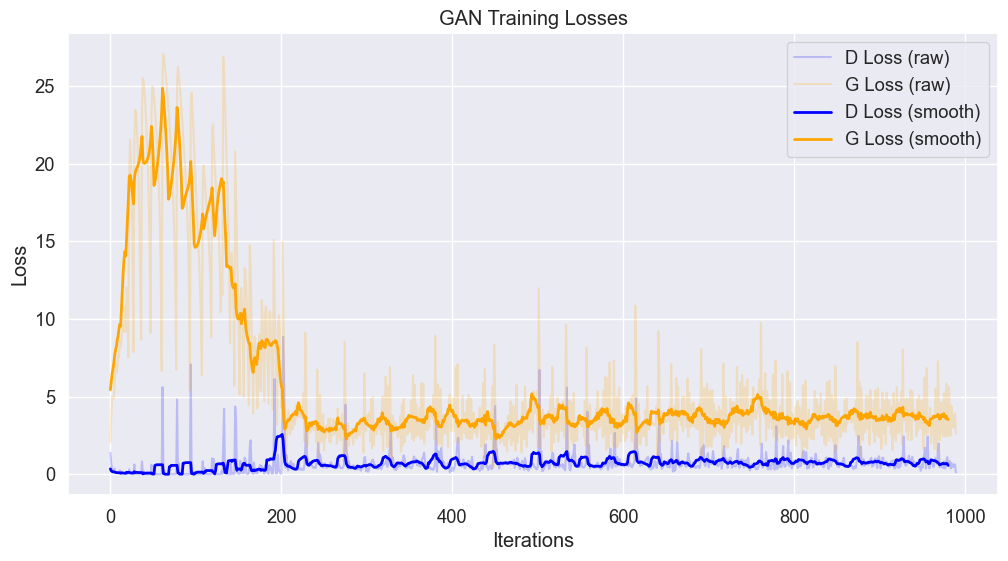

In [29]:
history = {'D_losses':losses_D, 'G_losses':losses_G }
plot_gan_losses(history)

### Обучение 100 эпох

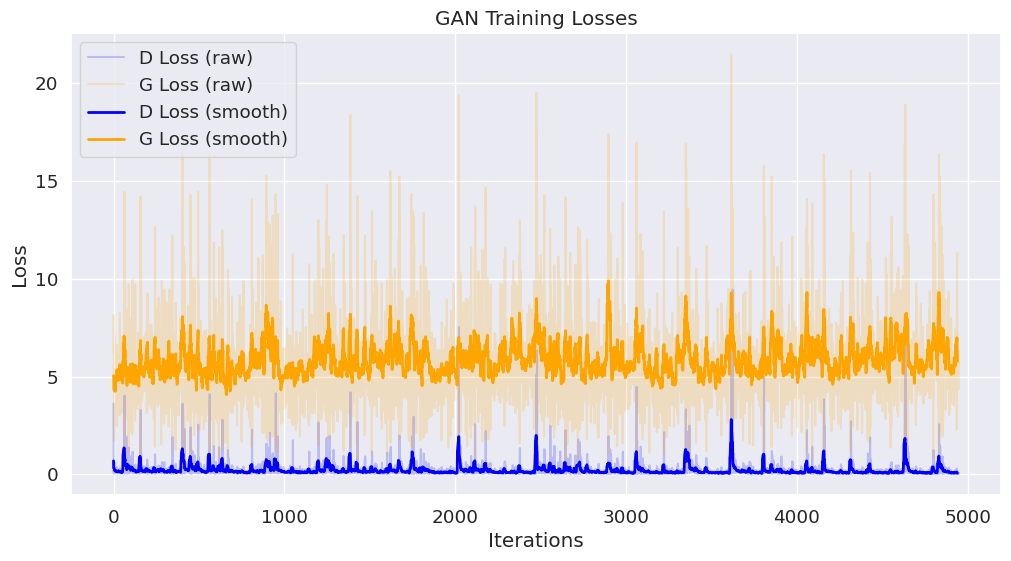

In [19]:
history = {'D_losses':losses_D, 'G_losses':losses_G }
plot_gan_losses(history)

### **Вывод**

> Провел обучение двумя этапами 50 и 100 эпох. Проведено достаточное обучение, но графики потерь имеют большую вариативность и после 50 эпохи практически не сходятся. Скорее всего выбрана маленькая размерность латентного пространства (100) и слишком простой дискриминатор. Графики вывел со скользящим средним, чтобы уловить общую тенденцию снижения потерь.



## Часть 3. Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором

In [16]:
def show_images(generated, nrow=None, figsize=(10, 10)):
    """
    Отображает сгенерированные изображения

    Параметры:
        generated (torch.Tensor): Тензор с изображениями (N, C, H, W)
        nrow (int): Количество изображений в строке
        figsize (tuple): Размер фигуры matplotlib
    """
    # Преобразуем тензор в numpy и меняем порядок измерений для matplotlib
    generated = generated.detach().cpu().numpy()
    generated = np.transpose(generated, (0, 2, 3, 1))

    # Нормализуем из [-1, 1] в [0, 1] (если использовался Tanh в генераторе)
    generated = (generated + 1) / 2
    generated = np.clip(generated, 0, 1)

    n_images = generated.shape[0]
    if nrow is None:
        nrow = int(np.ceil(np.sqrt(n_images)))
    ncol = int(np.ceil(n_images / nrow))

    # Создаем фигуру
    fig, axes = plt.subplots(nrow, ncol, figsize=figsize)
    if nrow == 1 and ncol == 1:
        axes = np.array([[axes]])
    elif nrow == 1 or ncol == 1:
        axes = axes.reshape(nrow, ncol)

    # Отображаем изображения
    for i in range(nrow):
        for j in range(ncol):
            idx = i * ncol + j
            if idx < n_images:
                axes[i,j].imshow(generated[idx])
            axes[i,j].axis('off')

    plt.tight_layout()
    plt.show()

### Генератор 10 эпох

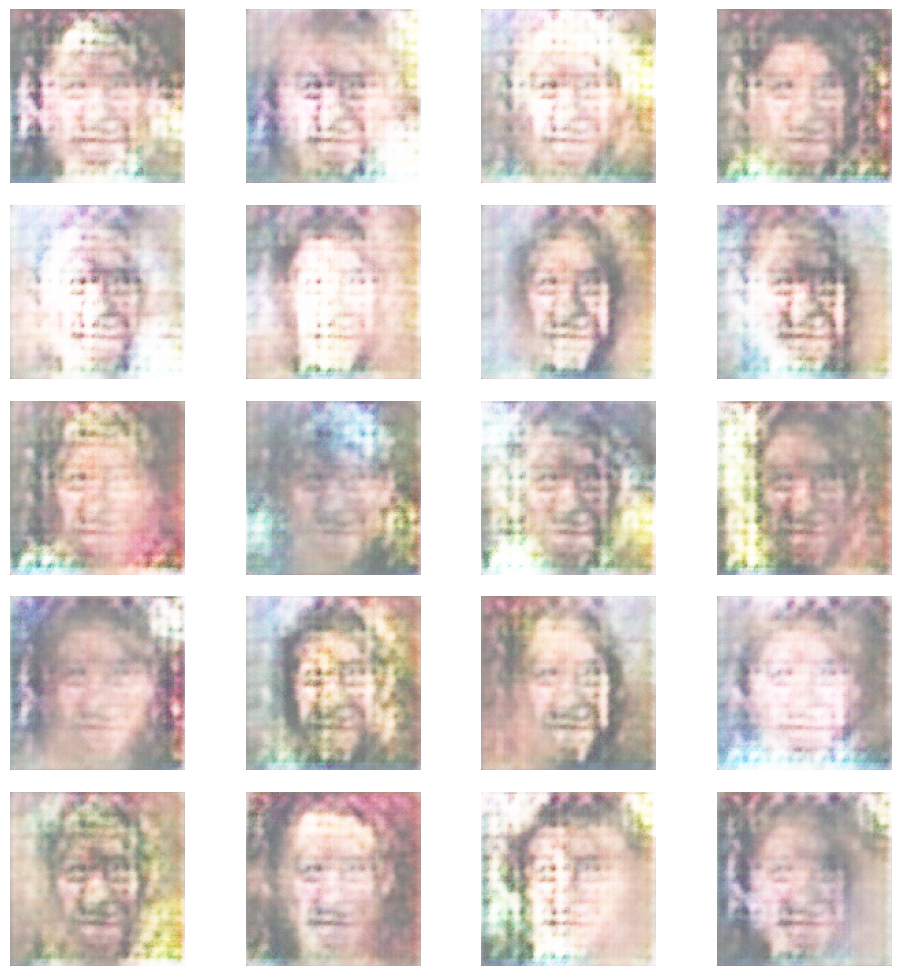

In [51]:
fixed_latent = torch.randn(20, 100, 1, 1, device=device)
fake_images = model["generator"](fixed_latent)
show_images(fake_images, nrow=5)

### Генератор 50 эпох

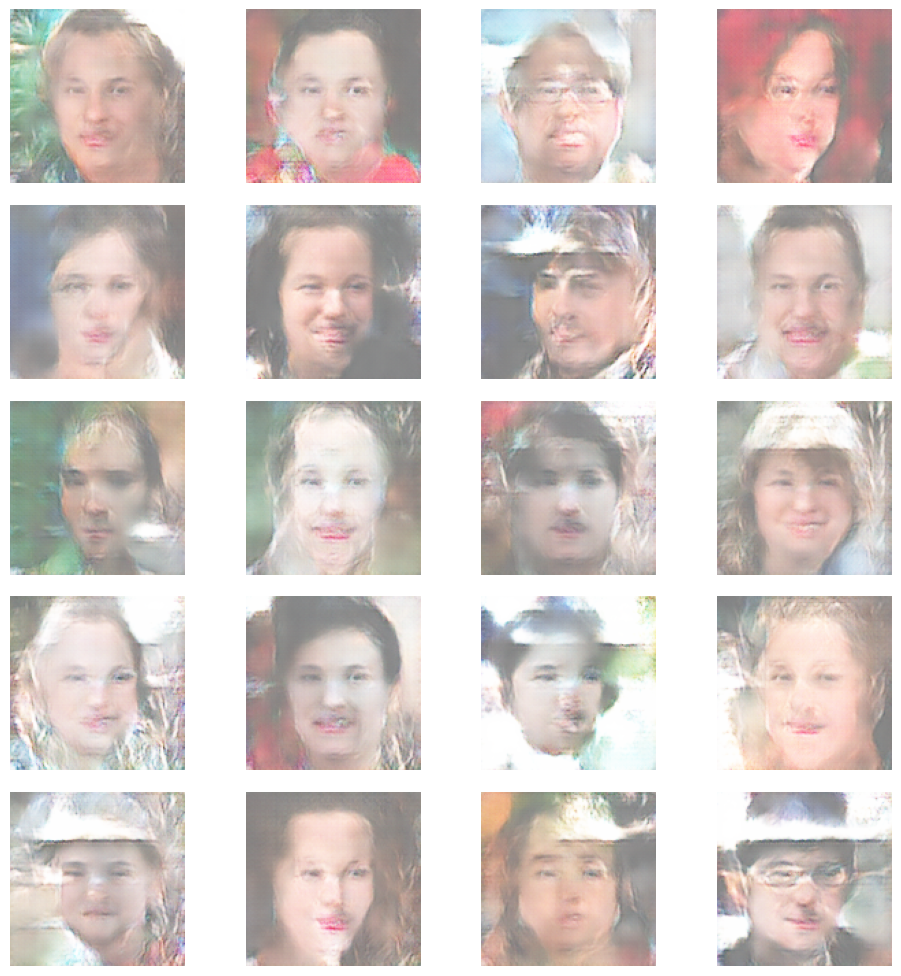

In [22]:
fixed_latent = torch.randn(20, 100, 1, 1, device=device)
fake_images = model["generator"](fixed_latent)
show_images(fake_images, nrow=5)

### Генератор 100 эпох

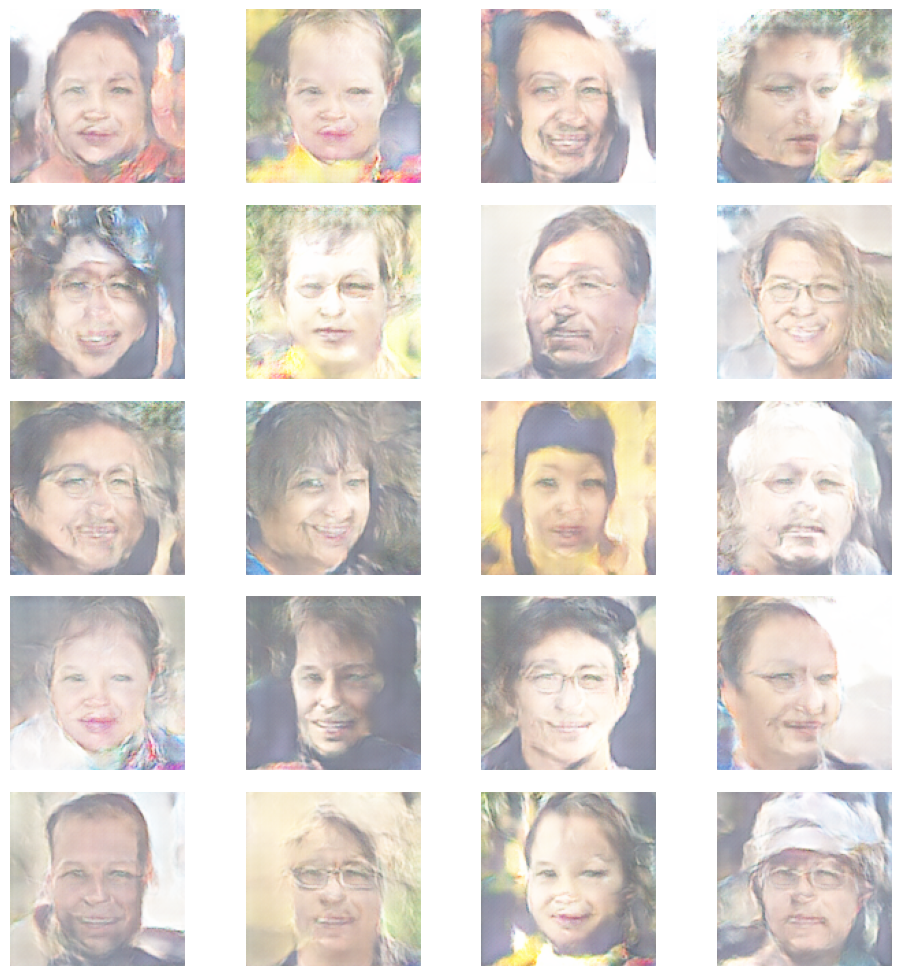

In [20]:
# Пример использования
fixed_latent = torch.randn(20, 100, 1, 1, device=device)
fake_images = model["generator"](fixed_latent)
show_images(fake_images, nrow=5)

Как вам качество получившихся изображений?

### **Вывод**

> Генерация изображений проводится хорошо, однако качество пока удовлетворительно. Скорее всего выбрана маленькая размерность латентного пространства (100) и слишком простой дискриминатор, который просто обмануть.

## Часть 4. Leave-one-out-1-NN classifier accuracy (6 баллов)

### 4.1. Подсчет accuracy (1.5 балл)

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативы вам предлагается реализовать следующий подход:
  * Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить фейковым метку класса 0, настоящим – 1.
  * Построить leave-one-out оценку: обучить 1NN Classifier (`sklearn.neighbors.KNeighborsClassifier(n_neighbors=1)`) предсказывать класс на всех объектах, кроме одного, проверить качество (accuracy) на оставшемся объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`

In [21]:
real_dataloader = get_dataloader(2)

In [22]:
# Датасет для подачи реальных и фиктивных изображений
class MixedDataset(Dataset):
    def __init__(self, real_dataloader, generator, num_real_samples, device="cpu"):
        self.device = device
        self.generator = generator.to(device)
        self.generator.eval()

        # Загружаем все реальные изображения
        self.real_images = []
        for batch in real_dataloader:
            self.real_images.append(batch)
        self.real_images = torch.cat(self.real_images, dim=0)

        # Генерируем фейковые изображения
        with torch.no_grad():
            noise = torch.randn(num_real_samples, latent_size, 1, 1, device=device)
            self.fake_images = generator(noise).cpu()

        # Метки: 0 для фейков, 1 для реальных
        self.labels = torch.cat([
            torch.zeros(len(self.fake_images)),
            torch.ones(len(self.real_images))
        ])

        # Объединяем все изображения
        self.all_images = torch.cat([self.fake_images, self.real_images], dim=0)

    def __len__(self):
        return len(self.all_images)

    def __getitem__(self, idx):
        return self.all_images[idx], self.labels[idx]


### Тестирование Dataloader

In [23]:
# Пусть real_dataloader уже загружен с 3100 изображениями (128x128)

print(f"Количество реальных изображений: {len(real_dataloader.dataset)}")  # Должно быть 3100

generator = model["generator"]
generator.eval()

mixed_dataset = MixedDataset(
    real_dataloader=real_dataloader,
    generator=generator,
    num_real_samples=len(real_dataloader.dataset),  # 3100 фейков
    device="cuda" if torch.cuda.is_available() else "cpu"
)

# Проверяем размер
print(f"Общий размер датасета: {len(mixed_dataset)}")  # Должно быть 6200 (3100 фейков + 3100 реальных)

Количество реальных изображений: 3143
Общий размер датасета: 6286


### Вывод изображений

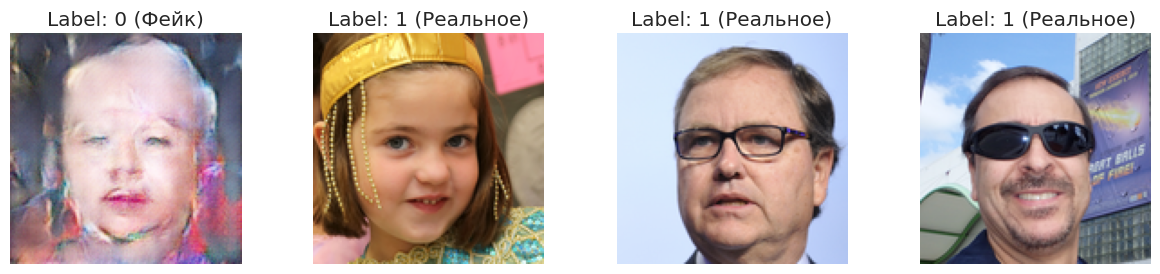

In [24]:
def plot_images(dataset, num_samples=4):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        img = img.permute(1, 2, 0).numpy()  # CHW -> HWC
        img = (img - img.min()) / (img.max() - img.min())  # Нормализация [0, 1]
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {int(label)} ({'Фейк' if label == 0 else 'Реальное'})")
        axes[i].axis("off")
    plt.show()

plot_images(mixed_dataset)

In [33]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Преобразуем mixed_dataset в numpy массивы
X = []
y = []
for i in range(len(mixed_dataset)):
    img, label = mixed_dataset[i]
    X.append(img.flatten().numpy())  # Преобразуем изображение в вектор (128*128*3)
    y.append(label.item())  # Метка (0 или 1)

X = np.array(X)  # Размер: (n_samples, 128*128*3)
y = np.array(y)  # Размер: (n_samples,)

In [34]:

# 2. Нормализация данных (рекомендуется для KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:

# 3. Инициализация 1NN и LOO
knn = KNeighborsClassifier(n_neighbors=1)
loo = LeaveOneOut()

In [36]:
len(list(loo.split(X_scaled)))

6286

In [37]:
len(X_scaled[0])

49152

In [38]:
X_scaled = X_scaled[:1000]
y = y[:1000]

In [39]:

# 4. Вычисление LOO accuracy
y_true = []
y_pred = []

for train_idx, test_idx in loo.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)

    y_true.append(y_test[0])
    y_pred.append(pred[0])

accuracy = accuracy_score(y_true, y_pred)
print(f"Leave-One-Out Accuracy: {accuracy:.4f}")

Leave-One-Out Accuracy: 1.0000


Что вы можете сказать о получившемся результате? Какой accuracy мы хотели бы получить и почему?

### **Вывод**

> Здесь провел много экспериментов. Скорее всего Дискриминатор переобучился и плохо определяет фейковые изображения.

### 4.2. Визуализация распределений (1 балл)

Давайте посмотрим на то, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом, снижающим размерность (к примеру, TSNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображенияи

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Подготовка данных
X = []
y = []
for i in range(len(mixed_dataset)):
    img, label = mixed_dataset[i]
    X.append(img.flatten().numpy())  # (3*128*128,)
    y.append(label.item())  # 0 (фейк) или 1 (реальное)

X = np.array(X)  # (n_samples, 49152)
y = np.array(y)  # (n_samples,)

In [41]:

# 2. Уменьшение размерности (чтобы ускорить t-SNE)
pca = PCA(n_components=50)  # Сначала сжимаем до 50 компонент
X_pca = pca.fit_transform(X)

In [42]:

# 3. Применяем t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


### Распределение 10 эпох

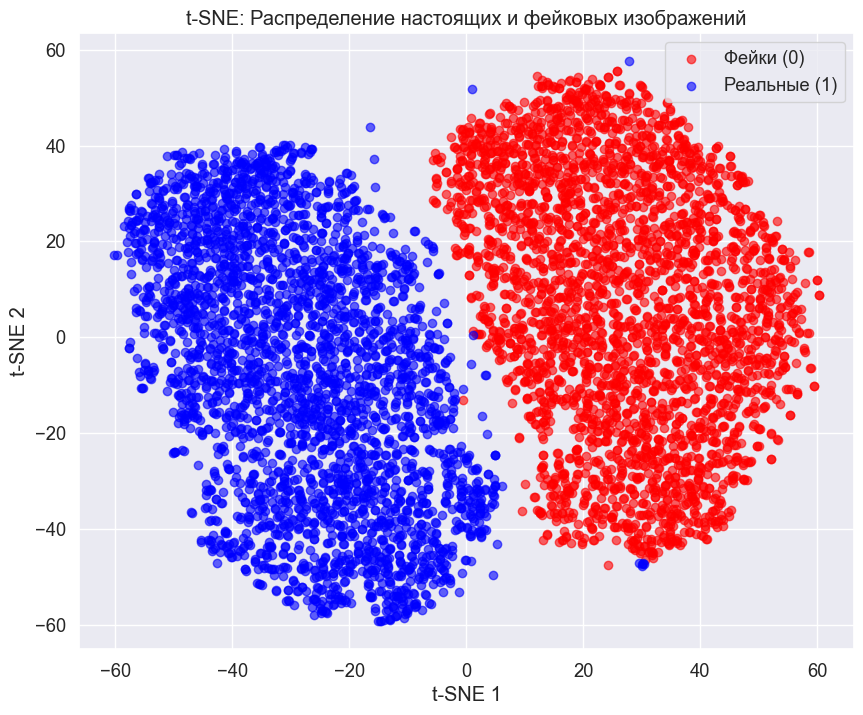

In [64]:
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[y == 0, 0], X_tsne[y == 0, 1], c='red', label='Фейки (0)', alpha=0.6)
plt.scatter(X_tsne[y == 1, 0], X_tsne[y == 1, 1], c='blue', label='Реальные (1)', alpha=0.6)
plt.title('t-SNE: Распределение настоящих и фейковых изображений')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True)
plt.show()

### Распределение 50 эпох

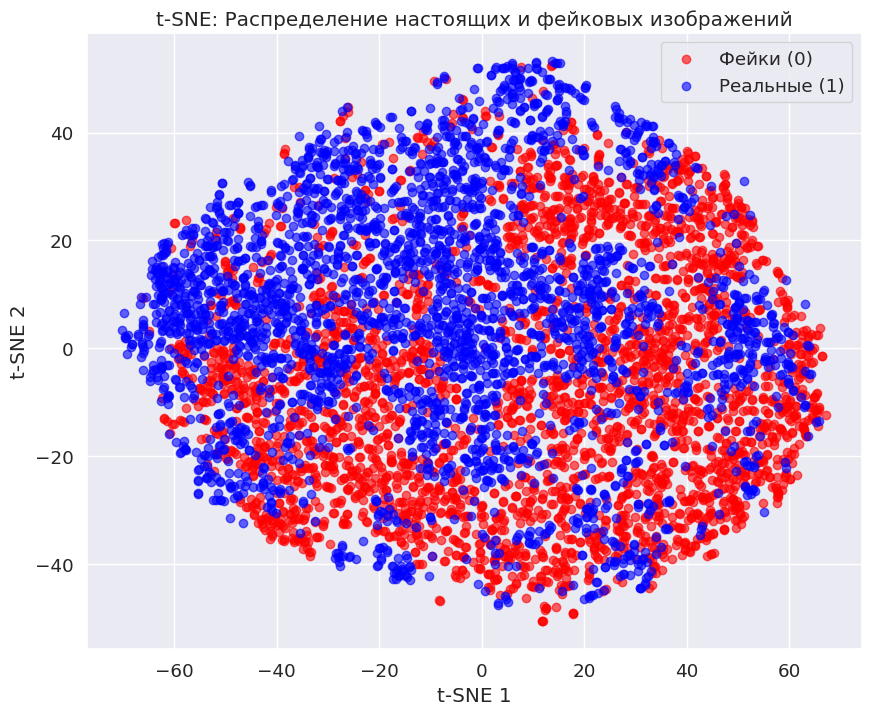

In [43]:
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[y == 0, 0], X_tsne[y == 0, 1], c='red', label='Фейки (0)', alpha=0.6)
plt.scatter(X_tsne[y == 1, 0], X_tsne[y == 1, 1], c='blue', label='Реальные (1)', alpha=0.6)
plt.title('t-SNE: Распределение настоящих и фейковых изображений')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True)
plt.show()

### Распределение 100 эпох

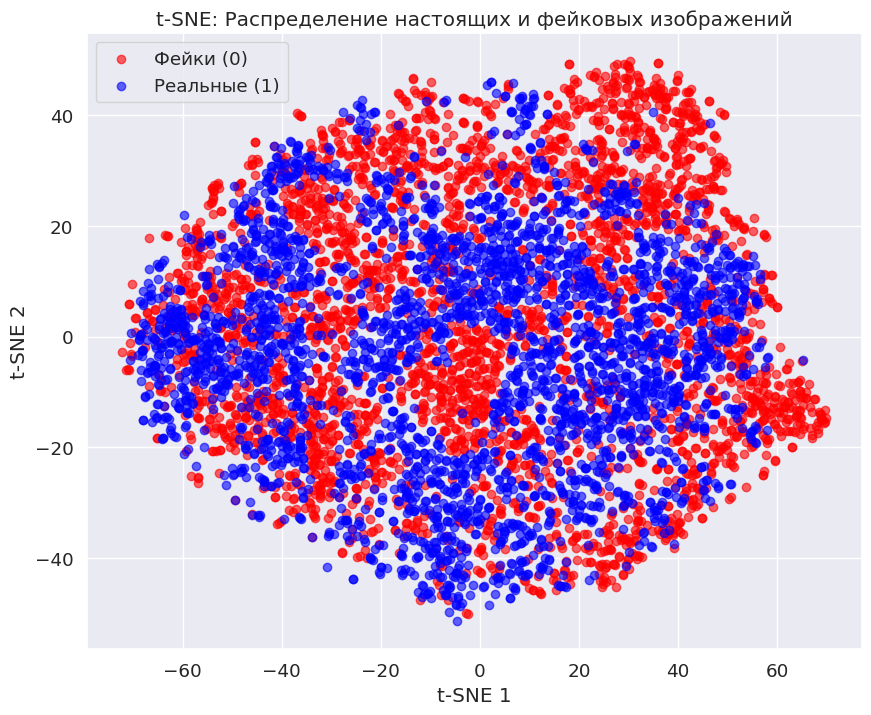

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[y == 0, 0], X_tsne[y == 0, 1], c='red', label='Фейки (0)', alpha=0.6)
plt.scatter(X_tsne[y == 1, 0], X_tsne[y == 1, 1], c='blue', label='Реальные (1)', alpha=0.6)
plt.title('t-SNE: Распределение настоящих и фейковых изображений')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True)
plt.show()

Прокомментируйте получившийся результат:

### Вывод

> Видим что при увеличении обучения и повышения качества обучения картинки и фейки более равномерно распределены. Однако пока еще видны отдельные мелкие кластеры. Очевидно что при дальнейшем повышении качества генерации взаимное проникновение кластеров должно усиливаться и кластеры уменьшаться.